# SED

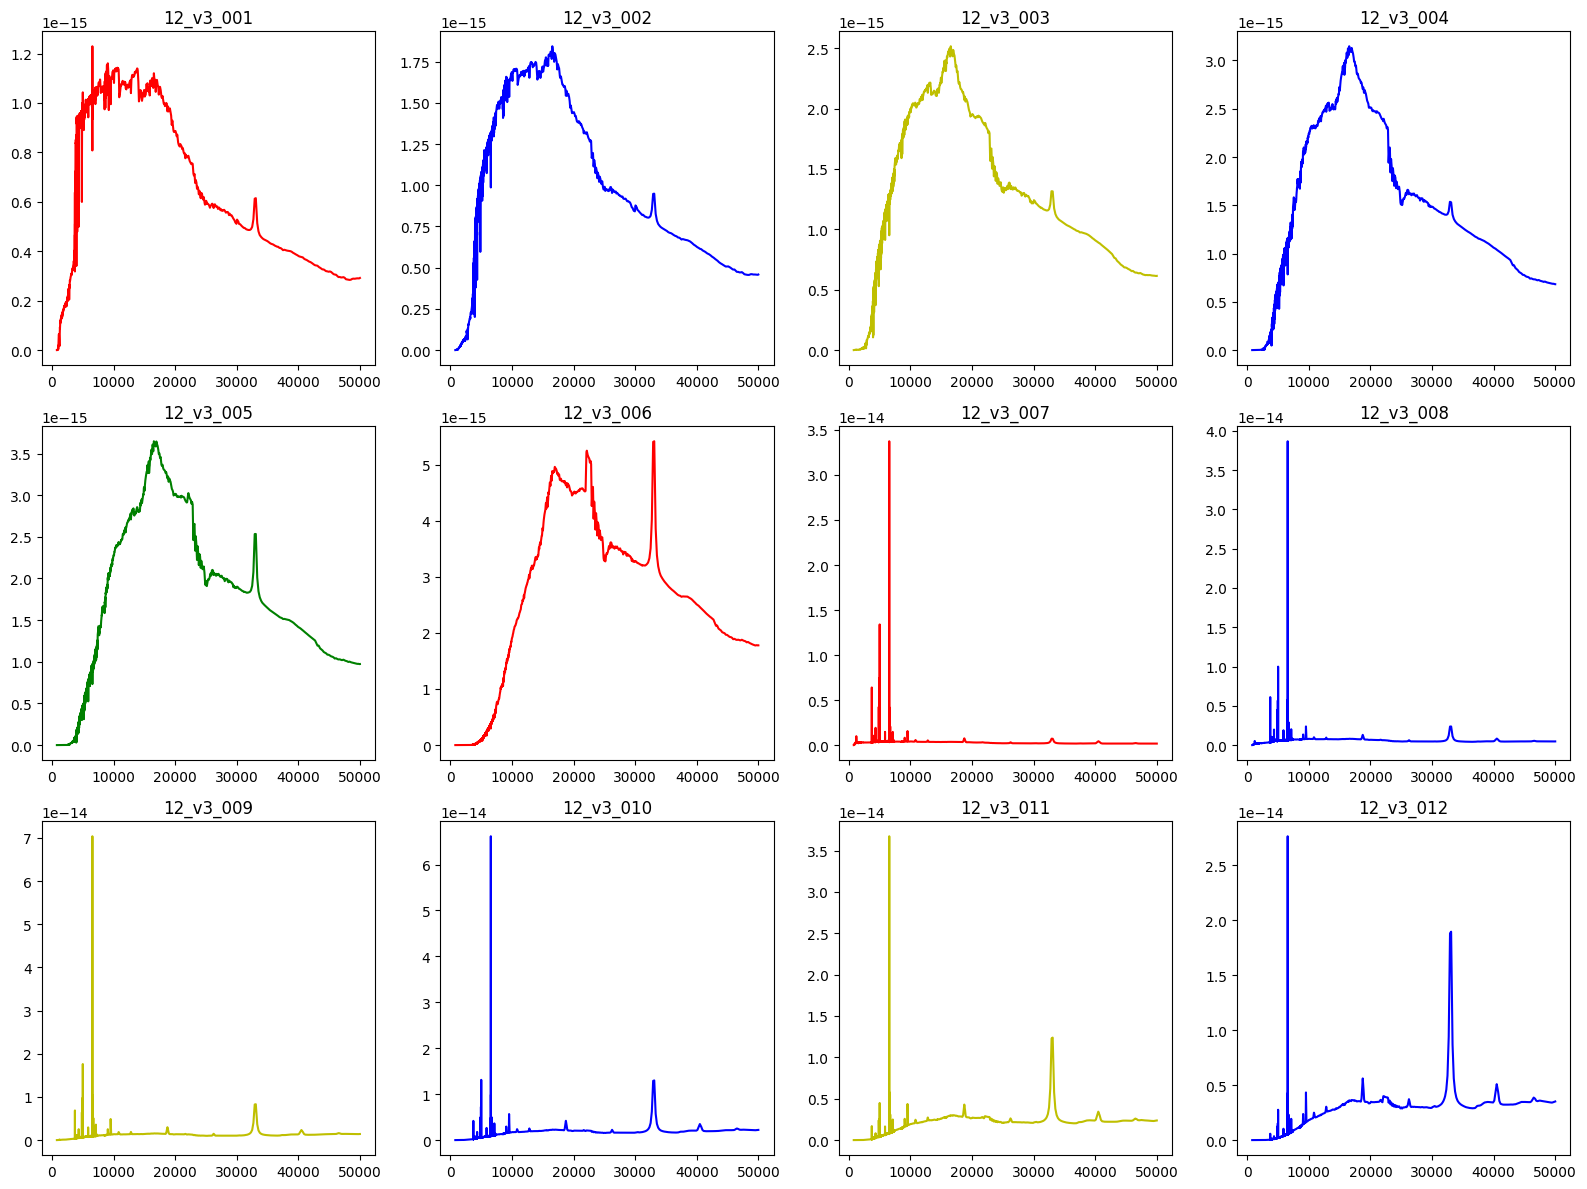

In [9]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

# Files
files = glob('fsps/*')

# Common wavelength grid (uniform in λ)
wave_grid = np.linspace(800, 50000, 20000)
dlam = np.gradient(wave_grid)   # needed for proper L1

# Storage
flux_interp_L1 = {}

# Plot setup
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
colors = ['r', 'b', 'g', 'y']

c_angstrom = 2.99792458e18 

for idx, fname in enumerate(files):
    wave, flux_lam = np.loadtxt(fname, unpack=True)
    flux_lam_interp = np.interp(wave_grid, wave, flux_lam)

    flux_nu_interp = flux_lam_interp * (wave_grid**2) / c_angstrom
    nu_grid = c_angstrom / wave_grid
    dnu = np.abs(np.gradient(nu_grid))
    
    area = np.sum(flux_nu_interp * dnu)
    flux_L1 = flux_nu_interp / area
    flux_interp_L1[fname] = flux_L1

    # Plot
    ax = axes[idx]
    ax.plot(wave_grid, flux_L1, color=np.random.choice(colors))
    ax.set_title(fname[-13:-4])

# Turn off unused panels
for idx in range(len(files), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [10]:
flux_list = []
for name in flux_interp_L1.keys():
    flux_list.append(flux_interp_L1[name])

X = np.array(flux_list)

In [11]:
from sklearn.decomposition import NMF
model = NMF(4, init='random', random_state=0)
W = model.fit_transform(X)
H = model.components_

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sklearn\decomposition\_nmf.py:1759: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


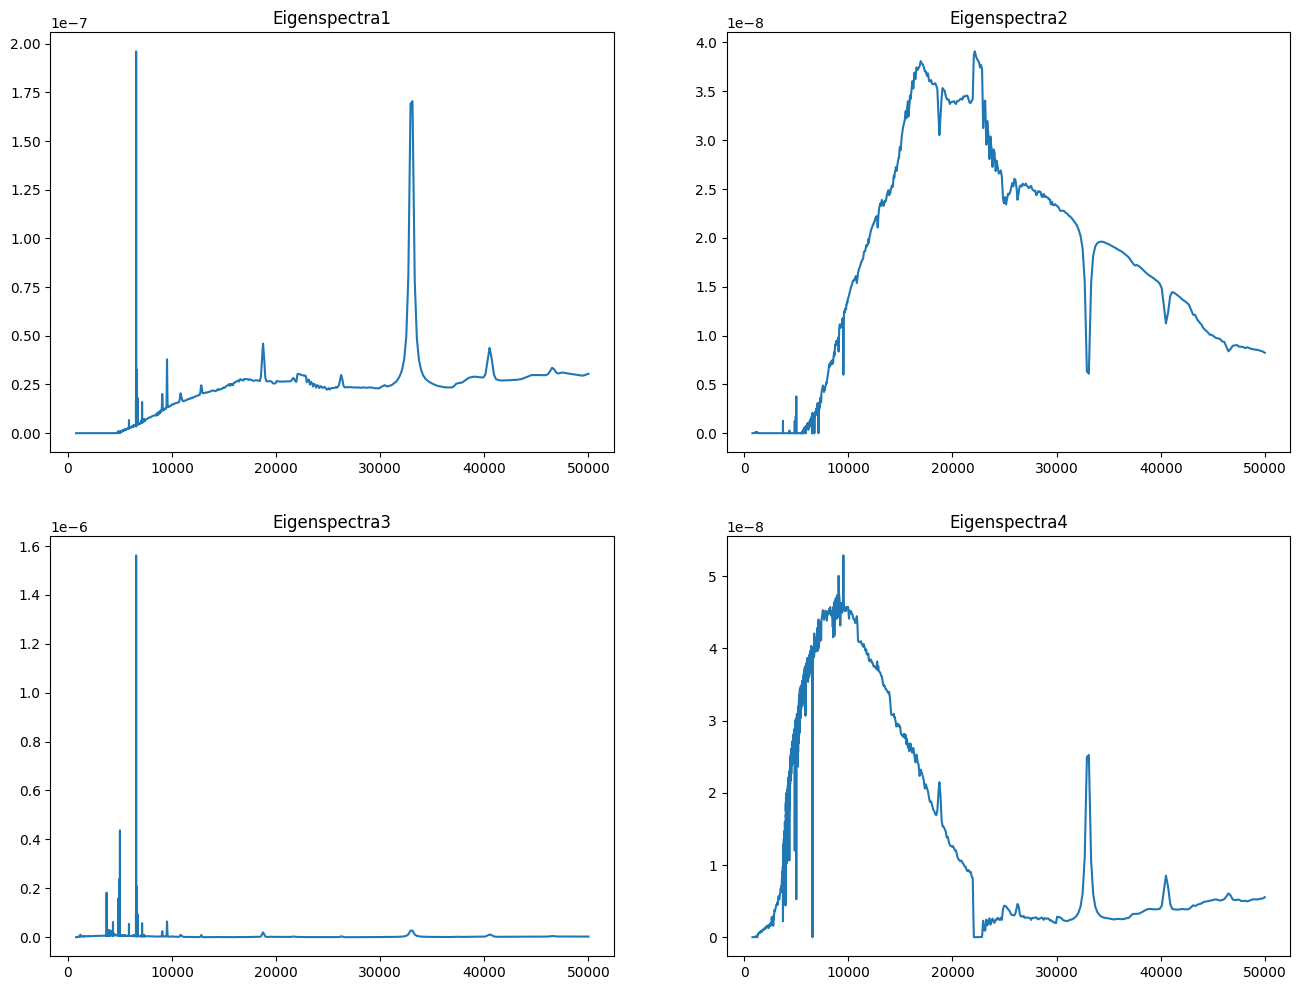

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axs=axes.flatten()
for i in range(len(H)):
    ax = axs[i]
    ax.plot(wave_grid, H[i])
    ax.set_title(f'Eigenspectra{i+1}')

# Redshifting PCA components

In [8]:
from sedpy.observate import getSED, load_filters

fil=['cfht_u','hsc_g','sc_IB427','sc_IB464','subaru_suprimecam_ia484','sc_IB505','subaru_suprimecam_ia527','hsc_r','sc_IB574','subaru_suprimecam_ia624','subaru_suprimecam_ia679','hsc_i','sc_IB709','subaru_suprimecam_ia738',
    'subaru_suprimecam_ia767','sc_IB827','sc_NB711','sc_NB816','hsc_z','hsc_y','vista_vircam_Y','vista_vircam_J','vista_vircam_H','vista_vircam_Ks','irac_ch1','irac_ch2']

filters = load_filters(fil)

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename, resource_listdir


In [6]:
z_grid=np.linspace(0,8,501)
z_grid=z_grid[1:]

In [7]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)

In [8]:
f_z = {}
wave_z = {}
H = np.asarray(H)
wave_grid = np.asarray(wave_grid)

for z in z_grid:
    lam_obs=wave_grid * (1 + z)
    wave_z[z] = lam_obs
    dL = cosmo.luminosity_distance(z).value * 1e6  
    denom = (1 + z) * 4 * np.pi * dL**2
    #rest_waves = wave_grid / (1 + z)
    H_interp = np.array([np.interp(wave_grid, wave_grid, H_j)* 3631 * 1e6 for H_j in H])
    f = H_interp / denom
    f_z[z]=f

In [9]:
pca_f={}
for i in z_grid:
    f=getSED(wave_z[i],f_z[i],filters,linear_flux=True)* 3631 * 1e6
    pca_f[i]=f

C:\Users\pranav\AppData\Roaming\Python\Python312\site-packages\sedpy\observate.py:484: RuntimeWarning: divide by zero encountered in log10
  return -2.5 * np.log10(counts / self.ab_zero_counts)


In [10]:
pca_f[0]=getSED(wave_grid,H,filters,linear_flux=True)* 3631 * 1e6

In [11]:
last_key = list(pca_f.keys())[-1]
last_value = pca_f[last_key]

# 2. Remove the last key-value pair
del pca_f[last_key]

# 3. Create a new dictionary with the last element as first
new_dict = {last_key: last_value}
new_dict.update(pca_f)

pca_f=new_dict

z_grid1=np.insert(z_grid,0,0)

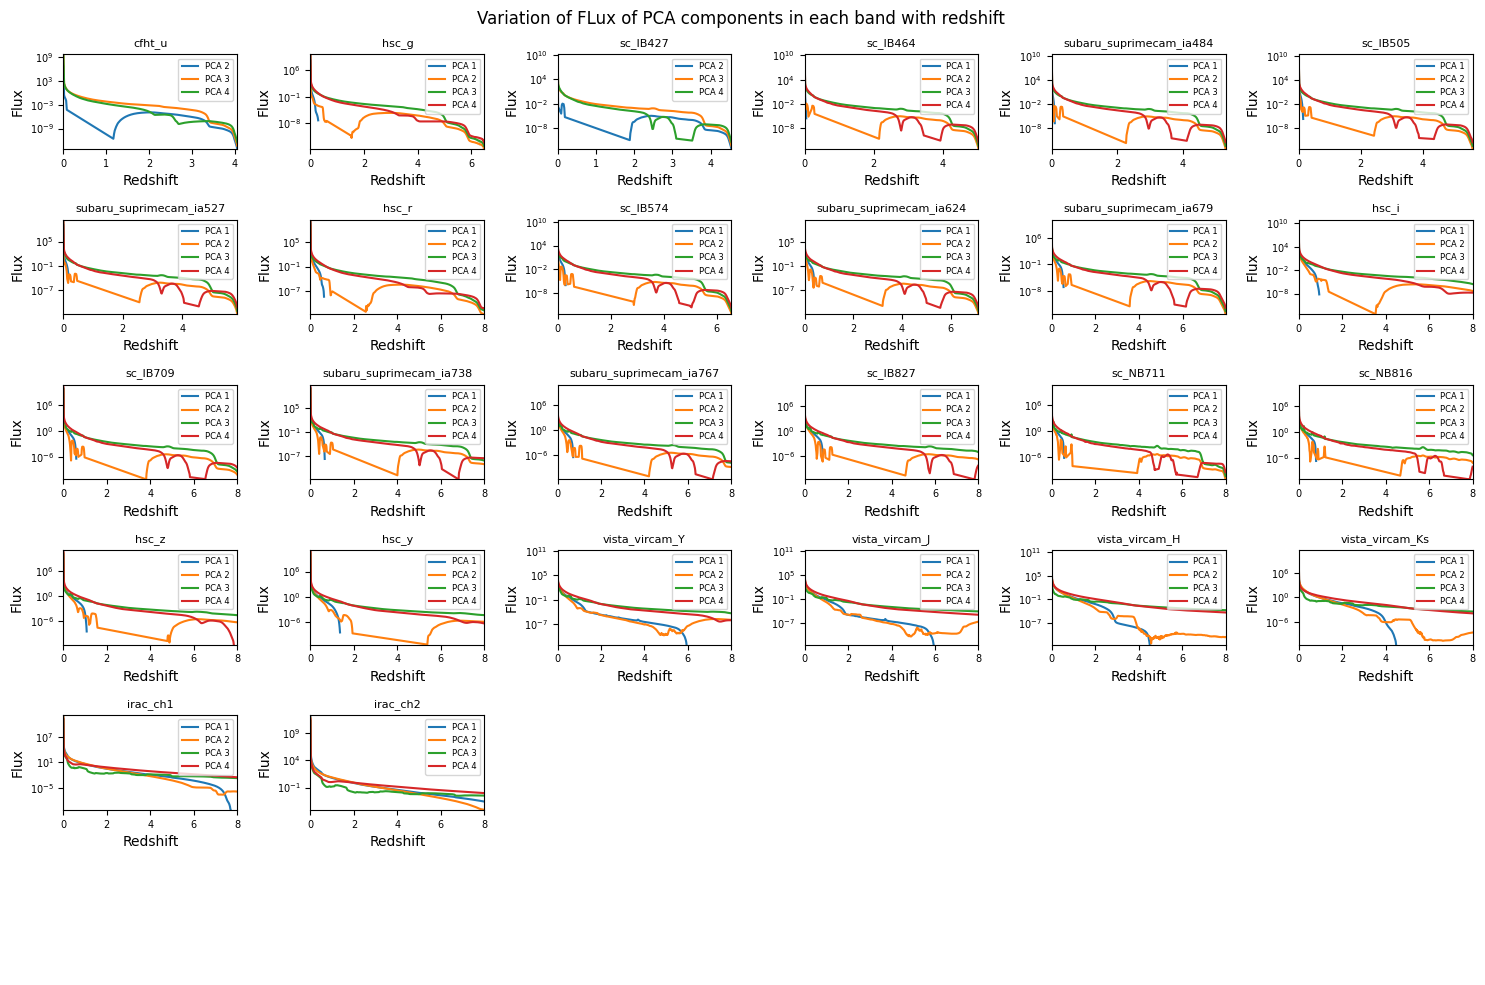

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Sort redshifts (keys)

# Convert f_z into a stacked array of shape (n_z, 4, 23)
f_all = np.array([pca_f[z] for z in z_grid1])  # shape: (n_z, 4, 23)
f_all = np.nan_to_num(f_all, nan=0.0)

n_pca, n_filters = f_all.shape[1], f_all.shape[2]

fig, axes = plt.subplots(6, 6, figsize=(15, 10), sharex=False, sharey=False)
axes = axes.flatten()

for filt_idx in range(n_filters):
    ax = axes[filt_idx]
    fluxes = f_all[:, :, filt_idx]  # shape (n_z, n_pca)
    
    for comp_idx in range(n_pca):
        flux = fluxes[:, comp_idx]
        
        # mask out regions where flux is zero or negligible
        mask = flux > 0
        if np.sum(mask) == 0:
            continue  # nothing to plot for this component
        
        # only keep valid parts of the curve
        z_valid = np.array(z_grid1)[mask]
        flux_valid = flux[mask]

        ax.plot(z_valid, flux_valid, label=f'PCA {comp_idx+1}')

    ax.set_title(f'{fil[filt_idx]}', fontsize=8)
    ax.set_xlabel('Redshift')
    ax.set_ylabel('Flux')
    ax.set_yscale('log')
    ax.tick_params(labelsize=7)
    ax.relim()
    ax.autoscale(enable=True, axis='both', tight=True)
    ax.legend(fontsize=6)

# Hide unused subplots
for ax in axes[n_filters:]:
    ax.axis('off')

# Legend only on the first plot

plt.suptitle('Variation of FLux of PCA components in each band with redshift')
plt.tight_layout()
plt.show()




In [13]:
np.save('pcaflux_w_redshift1.npy',f_all)

# Data

In [32]:
import numpy as np
from scipy.special import factorial, gamma as func_gamma, gammaincc as func_gammaincc

linewv = np.array([1215.67, 1025.72, 972.537, 949.743, 937.803, 930.748, 926.226,
                    923.150, 920.963, 919.352, 918.129, 917.181, 916.429, 915.824, 915.329, 914.919, 914.576, 914.286, 914.039, 913.826, 913.641, 913.480, 913.339, 913.215, 913.104, 913.006, 912.918, 912.839, 912.768, 912.703, 912.645, 912.592, 912.543, 912.499, 912.458, 912.420, 912.385, 912.353, 912.324])
Rn = np.array([1.00000000e+00, 2.77633136e-01, 1.32485207e-01,
                    7.80473373e-02, 5.15207101e-02, 3.65562130e-02, 
                    2.72721893e-02, 2.11183432e-02, 1.68224852e-02, 
                    1.37159763e-02, 1.13786982e-02, 9.59763314e-03, 
                    8.19526627e-03, 7.07692308e-03, 6.17159763e-03, 
                    5.42840237e-03, 4.80946746e-03, 4.29053254e-03, 
                    3.84911243e-03, 3.47218935e-03, 3.14733728e-03, 
                    2.86568047e-03, 2.61952663e-03, 2.40414201e-03, 
                    2.21183432e-03, 2.04378698e-03, 1.89289941e-03, 
                    1.75798817e-03, 1.63668639e-03, 1.52781065e-03, 
                    1.42899408e-03, 1.33905325e-03, 1.25798817e-03, 
                    1.18343195e-03, 1.11538462e-03, 1.05266272e-03, 
                    9.95266272e-04, 9.42603550e-04, 8.93491124e-04])[:,None]

def tau_eff(z):
    z_1= 1.2593846589041013
    a_1= 1.405759341921824
    A1= 0.01549433546364817
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565

    return np.piecewise(z,[z<z_1, z>=z_1], [lambda x:A1*((1.+x))**a_1, lambda z:A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))])

def tau_eff_highz(z):
    z_2= 5.174708845486191
    a_2= 3.6336748056970474
    a_3= 7.587297773671628
    delta= 0.030496534844542546
    A2=2.0448040499201565
    return A2*((1.+z)/(1.+z_2))**(a_2)*(0.5*(1.+((1.+z)/(1.+z_2))**(1./delta)))**(delta*(a_3-a_2))

def tau_lc_igm(zs, l_obs):
    lratio = l_obs/911.8
    tau_igm = 0.805*lratio**3. * (1/lratio - 1/(1+zs))
    return tau_igm

def tau_lc_lls(zs, l_obs, n0=0.15, beta=1.28, gamma=1.94, nterms = 10):
    lratio = l_obs/911.8 #ratio of observed wavelength to lyman limit, also z_LLS
    zs_p1 = 1+zs
    e_neg1 = 0.36787944117144233  #1/e
    if beta==1.28 and gamma==1.94:
        beta_m1 = 0.28
        gamma_p1 = 2.94
        gam_fn = 0.31340445237536
    else:
        gamma_p1 = gamma + 1
        beta_m1 = beta - 1
        gam_fn = func_gamma(2-beta,1)*func_gammaincc(2-beta,1)
        
    sum1 = _first_lls_sum(beta_m1,nterms)
    sum2 = _second_lls_sum(zs_p1, lratio, gamma_p1=gamma_p1, beta_m1=beta_m1, nterms=nterms)
    tau_lls = n0/(4+gamma-3*beta) * (gam_fn - e_neg1 - sum1) * ( zs_p1**(-3*beta_m1+gamma_p1) * lratio**(3*beta_m1) - np.power(lratio,gamma_p1)) - n0*sum2
    return tau_lls

def _first_lls_sum(beta_m1=0.28, nterms=10):
    #if default beta, nterms return precomputed
    if beta_m1 == 0.28 and nterms==10:
        return -1.3219480209375662
    else:
        # sums from n=0
        n = np.arange(0,nterms)
        return np.sum( (beta_m1) / (n - beta_m1) * (-1)**n / factorial(n) )

def _second_lls_sum(zs_p1, lratio, gamma_p1=2.94, beta_m1=0.28, nterms=10):
    # sums from n=1
    n = np.arange(1,1+nterms)[:,None] 
    if beta_m1 ==0.28 and gamma_p1 == 2.94 and nterms==10:
        gamma_3n_p1 = np.array([ 0.06,  3.06,  6.06,  9.06, 12.06, 15.06, 18.06, 21.06, 24.06,27.06])[:,None]
        term1 = np.array([-6.48148148e+00,  2.65997872e-02, -2.83116547e-03,
         3.46159020e-04, -4.09909024e-05,  4.51444675e-06,
        -4.57762778e-07,  4.27131736e-08, -3.67775581e-09,
         2.93360030e-10])[:,None]
    else:
        gamma_3n_p1 = 3*n - gamma_p1
        term1 = beta_m1 * (-1)**n / ( (gamma_3n_p1) * (n-beta_m1) * factorial(n) )
    term2 = zs_p1**(-gamma_3n_p1) * np.power(lratio, 3*n) - np.power(lratio,gamma_p1)
    return np.sum(term1*term2,axis=0)

def calc_transmission(z_s,l_obs,model='full', nlines = 30, z_lls=None):
    if z_lls is not None:
        if z_lls>z_s:
            raise ValueError('z_lls must be less than or equal to z_s or None')
    if nlines>39:
        raise ValueError('Maximum value for nlines is 39.')
    if model=='full':
        tau_lya = tau_eff
    elif model=='highz':
        tau_lya = tau_eff_highz
    elif model=='optimise':
        zbreak = 1.26
        if np.any(l_obs<zbreak):
            tau_lya = tau_eff
        else:
            tau_lya = tau_eff_highz
    zlook = np.outer(1./linewv[0:nlines],l_obs)-1
    tau_laf_i = np.zeros_like(zlook)
    mask_lya = zlook<z_s
    tau_laf_i[mask_lya] = tau_lya(zlook[mask_lya])
    tau_laf_i *= Rn[0:nlines]
    tau_lys = np.sum(tau_laf_i,axis=0)

    mask_lc = l_obs<911.8*(1.+z_s)
    tau_lc = np.zeros_like(l_obs)
    tau_lc[mask_lc] = tau_lc_igm(z_s,l_obs[mask_lc])

    tau_lls = np.zeros_like(l_obs)
    if z_lls is None:
        tau_lls[mask_lc] += tau_lc_lls(z_s,l_obs[mask_lc])
    else:
        lls_mask = l_obs<(911.8*(1+z_lls))
        tau_lls[lls_mask] = np.inf
    return np.exp(-(tau_lys+tau_lc+tau_lls))


In [1]:
import pandas as pd
df_flux = pd.read_feather("flux.feather")
df_err = pd.read_feather("error.feather")
df = pd.read_feather("original.feather")

In [2]:
df_err.columns

Index(['CFHT_u_FLUXERR_APER2', 'CFHT_ustar_FLUXERR_APER2',
       'HSC_g_FLUXERR_APER2', 'HSC_r_FLUXERR_APER2', 'HSC_i_FLUXERR_APER2',
       'HSC_z_FLUXERR_APER2', 'HSC_y_FLUXERR_APER2', 'UVISTA_Y_FLUXERR_APER2',
       'UVISTA_J_FLUXERR_APER2', 'UVISTA_H_FLUXERR_APER2',
       'UVISTA_Ks_FLUXERR_APER2', 'SC_IB427_FLUXERR_APER2',
       'SC_IB464_FLUXERR_APER2', 'SC_IA484_FLUXERR_APER2',
       'SC_IB505_FLUXERR_APER2', 'SC_IA527_FLUXERR_APER2',
       'SC_IB574_FLUXERR_APER2', 'SC_IA624_FLUXERR_APER2',
       'SC_IA679_FLUXERR_APER2', 'SC_IB709_FLUXERR_APER2',
       'SC_IA738_FLUXERR_APER2', 'SC_IA767_FLUXERR_APER2',
       'SC_IB827_FLUXERR_APER2', 'SC_NB711_FLUXERR_APER2',
       'SC_NB816_FLUXERR_APER2', 'UVISTA_NB118_FLUXERR_APER2',
       'SC_B_FLUXERR_APER2', 'SC_gp_FLUXERR_APER2', 'SC_V_FLUXERR_APER2',
       'SC_rp_FLUXERR_APER2', 'SC_ip_FLUXERR_APER2', 'SC_zp_FLUXERR_APER2',
       'SC_zpp_FLUXERR_APER2', 'IRAC_CH1_FLUXERR_APER2',
       'IRAC_CH2_FLUXERR_APER2', 'GALEX_FUV

In [3]:
df_flux=df_flux.drop(['CFHT_ustar_FLUX_APER2','SC_B_FLUX_APER2','SC_gp_FLUX_APER2','SC_V_FLUX_APER2','SC_rp_FLUX_APER2','SC_ip_FLUX_APER2','SC_zp_FLUX_APER2','SC_zpp_FLUX_APER2','GALEX_FUV_FLUX_APER2','GALEX_NUV_FLUX_APER2' ], axis=1)
df_err=df_err.drop(['CFHT_ustar_FLUXERR_APER2','SC_B_FLUXERR_APER2','SC_gp_FLUXERR_APER2','SC_V_FLUXERR_APER2','SC_rp_FLUXERR_APER2','SC_ip_FLUXERR_APER2','SC_zp_FLUXERR_APER2','SC_zpp_FLUXERR_APER2','GALEX_FUV_FLUXERR_APER2','GALEX_NUV_FLUXERR_APER2' ], axis=1)

In [4]:
df_flux=df_flux.iloc[:, [0, 1,10,11,12,13,14,2,15,16,17,3,18,19,20,21,22,23,4,5,6,7,8,9,25,26]]
df_err=df_err.iloc[:, [0, 1,10,11,12,13,14,2,15,16,17,3,18,19,20,21,22,23,4,5,6,7,8,9,25,26]]

In [5]:
len(df_flux.columns)

26

# Coefficients without IGM affected filters (Step 1)

In [15]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters
from scipy.interpolate import RegularGridInterpolator
import time
import matplotlib.pyplot as plt
plt.clf()

lam=[]
for i in filters:
    lam.append(np.percentile(i.wavelength,5))
lam = np.asarray(lam)  

f_all = np.load('pcaflux_w_redshift1.npy')   # shape: (Nz, Kc, Nbands)
z_grid1=np.load('zgrid.npy')
f_interp_vec = RegularGridInterpolator((z_grid1,), f_all, bounds_error=False, fill_value=None)

alpha3 = np.load('alpha3.npy')
N_bands = len(fil)
Kc = 4
LL=[]

z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z) & (z<8)

z = z[mask]
Y = np.asarray(df_flux[mask], dtype=float)
S = np.asarray(df_err[mask], dtype=float)
R = S**2

N, M = Y.shape
assert M == N_bands
Sigma_c = np.cov(alpha3, rowvar=False)

try:
    Sigma_c_inv = np.linalg.inv(Sigma_c)
except:
    Sigma_c_inv = np.linalg.pinv(Sigma_c)

mu=np.mean(alpha3)
batch_size = 50000

start = time.time()
bi_all_initial = np.zeros((N, Kc))   # store full posterior means
batch_idx = 0               # counter to fill bi_all

for b_start in range(0, N, batch_size):
    
    b_end = min(b_start + batch_size, N)
    Yb, Rb = Y[b_start:b_end], R[b_start:b_end]
    zb = z[b_start:b_end]
    lya_obs = 1216.0 * (1.0 + zb)          
    igm_mask = lam[None, :] >= lya_obs[:, None]       # (B, M) True=keep

    finite_mask = np.isfinite(Yb) & np.isfinite(Rb)   # (B, M) True=usable
    
    keep_mask = igm_mask & finite_mask
    b = keep_mask.astype(float)                 

    B = b_end - b_start

    Fz = f_interp_vec(zb)
    Yb0 = np.nan_to_num(Yb, nan=0.0, posinf=0.0, neginf=0.0)
    Rb0 = np.nan_to_num(Rb, nan=np.inf, posinf=np.inf, neginf=np.inf)
    Rinv = 1.0 / np.maximum(Rb0,1e-6)*b

    Ai = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)
    Ai_full = Ai + Sigma_c_inv[None, :, :]
    try:
        Bi = np.linalg.inv(Ai_full)
    except:
        Bi = np.linalg.pinv(Ai_full)

    rhs1 = np.einsum('bkm,bm->bk', Fz, Rinv * Yb0)
    mu_batch = np.broadcast_to(mu, (B, Kc))
    mu_i_Sigma_inv = np.einsum('bk,kl->bl', mu_batch, Sigma_c_inv)

    bi = np.einsum('bij,bj->bi', Bi, mu_i_Sigma_inv + rhs1)

    # Store the results
    bi_all_initial[b_start:b_end] = bi

<Figure size 640x480 with 0 Axes>

All batches processed. Generating plots...


<Figure size 640x480 with 0 Axes>

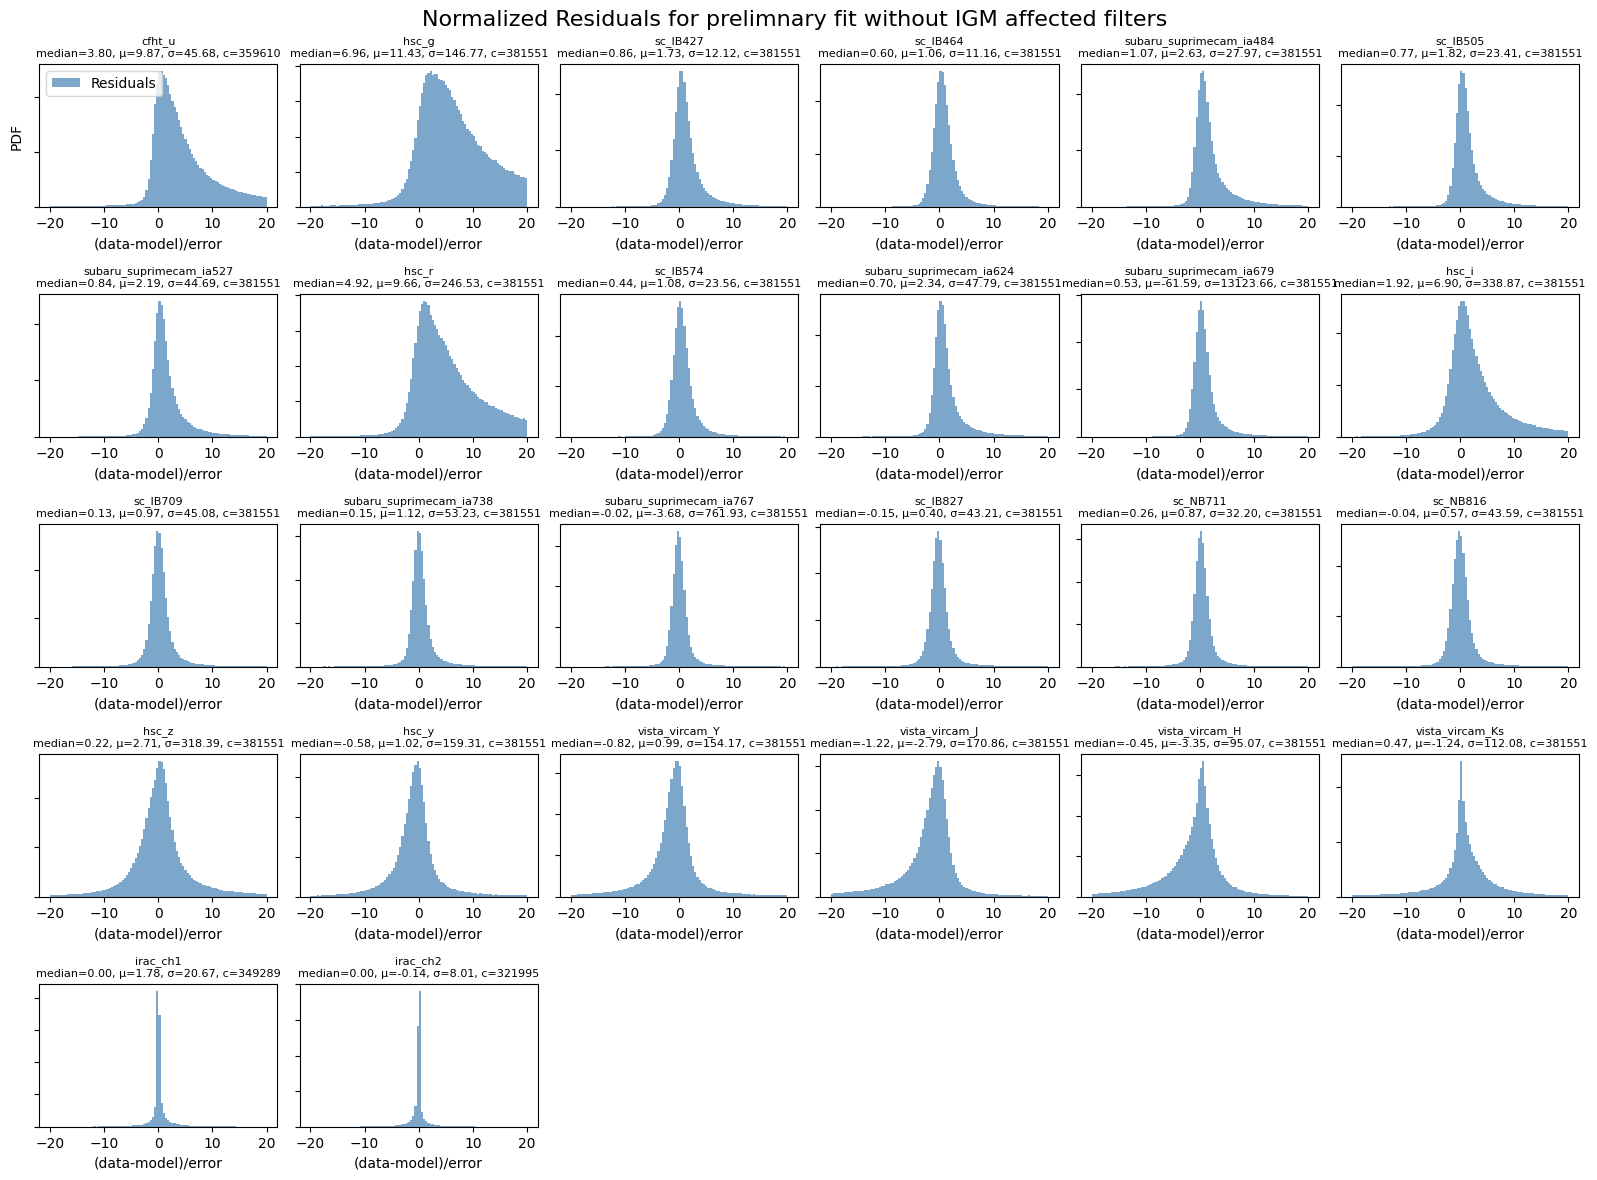

<Figure size 640x480 with 0 Axes>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.interpolate import RegularGridInterpolator
from sedpy.observate import load_filters
plt.clf()
filters = load_filters(fil)

batch_size = 50000

fig, axes = plt.subplots(5, 6, figsize=(16, 12))
axes = axes.flatten()
N_bands = len(fil)


if len(axes) < N_bands:
    N_bands_to_plot = len(axes)
else:
    N_bands_to_plot = N_bands

all_residuals = [[] for _ in range(N_bands_to_plot)]



galaxy_coefficients = bi_all_initial

c = f_interp_vec(z)

model_fluxes_batch = np.einsum('nk,nkb->nb', galaxy_coefficients, c)

data_batch = df_flux.to_numpy()
error_batch = df_err.to_numpy()
lya_obs_all = 1216.0 * (1.0 + z)

for i in range(N_bands_to_plot):
    
    data = data_batch[:, i]
    error = error_batch[:, i]
    model = model_fluxes_batch[:, i]

    is_not_affected = lam[i] >= lya_obs_all

    mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6)
    
    data_m = data[mask]
    error_m = error[mask]
    model_m = model[mask]

    if len(data_m) == 0:
        continue

    r_batch = (data_m - model_m) / error_m
    
    all_residuals[i].append(r_batch)

print("All batches processed. Generating plots...")

for i in range(N_bands_to_plot):
    ax = axes[i]
    
    if not all_residuals[i]:
        ax.set_title(f"{fil[i]}\nNo valid data")
        continue
        
    r = all_residuals[i]

    ax.hist(r, bins=100, range=(-20,20), density=True, alpha=0.7, color='steelblue', label='Residuals')    
    mu, median, sd, count = np.nanmean(r), np.nanmedian(r), np.nanstd(r), len(r[0])
    ax.set_title(f"{fil[i]}\nmedian={median:.2f}, μ={mu:.2f}, σ={sd:.2f}, c={count}", fontsize=8)
    #ax.set_yscale('log')
    ax.set_xlabel("(data-model)/error")
    ax.set_yticklabels([])
    

axes[0].set_ylabel("PDF")
axes[0].legend()

for j in range(N_bands_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Normalized Residuals for prelimnary fit without IGM affected filters', fontsize=16)
plt.tight_layout()
plt.savefig('Step1.png')
plt.show()
plt.tight_layout()


In [26]:
bi_all_initial

array([[ 8.67231375e-01, -6.13530577e-01,  5.02743996e-01,
        -4.57480811e-02],
       [-4.58175620e-01,  3.28893630e-01,  1.47493234e-01,
         4.49698157e-02],
       [ 1.93541649e+02, -1.08787289e+02,  1.09520897e+02,
        -4.27879582e+01],
       ...,
       [-4.55184475e+01,  3.31518028e+01,  4.02836831e+01,
         1.18831692e+01],
       [-8.58390918e-01,  8.74713585e-01,  5.42767527e+00,
         3.39484091e-01],
       [ 5.80586722e+02, -3.76070066e+02,  2.67188665e+02,
        -8.77464013e+01]])

NameError: name 'T_lam0_all' is not defined

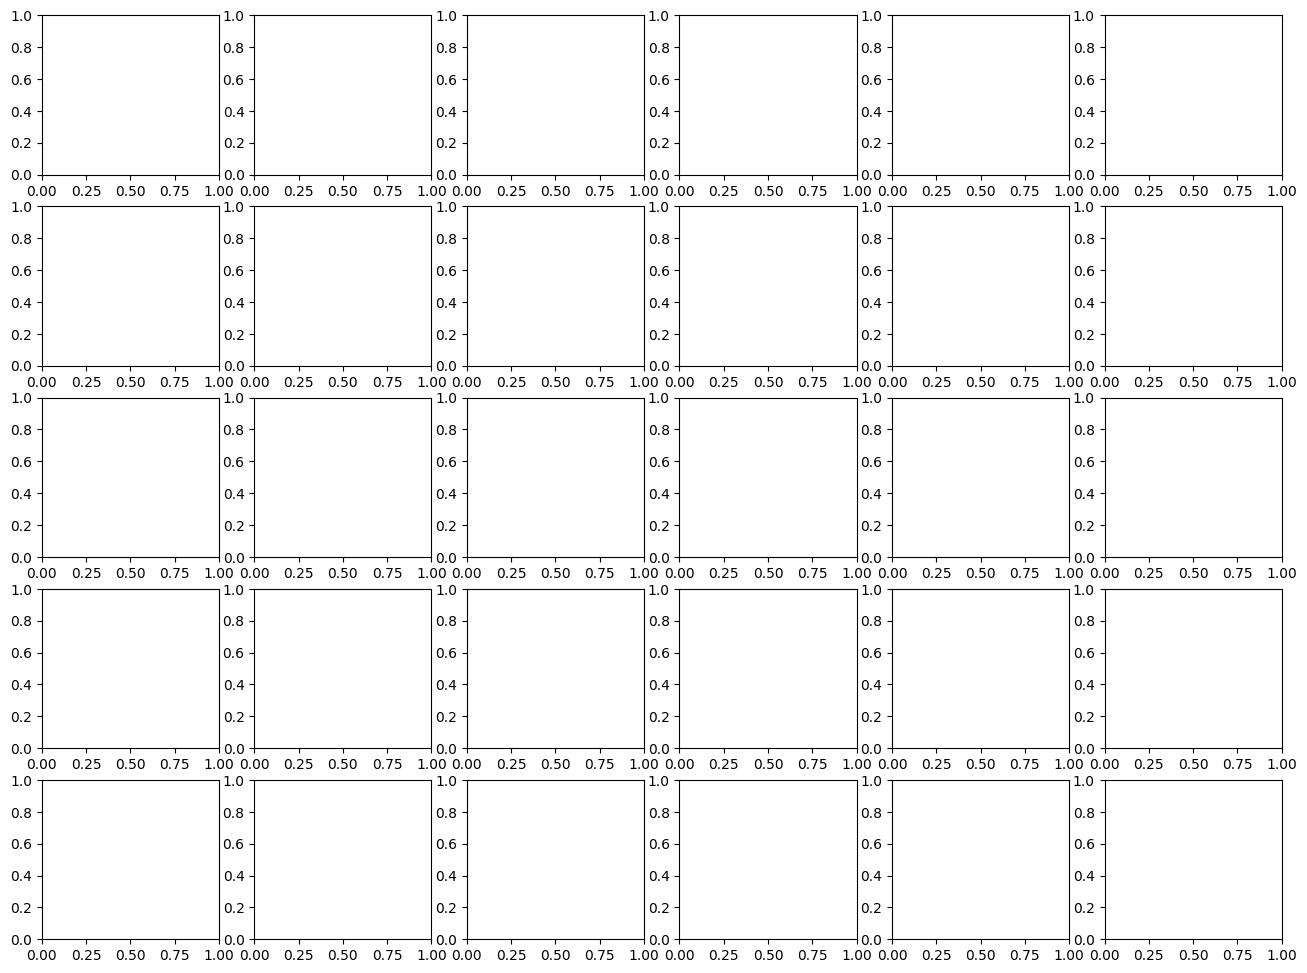

In [17]:
fig, axes = plt.subplots(5, 6, figsize=(16, 12))
axes = axes.flatten()
N_bands = len(fil)
for i in range(N_bands):
    ax = axes[i]
    ax.scatter(z,T_lam0_all[:,i],s=5) 
    ax.set_title(f"{fil[i]}", fontsize=8)
    #ax.set_yscale('log')
    ax.set_xlabel("redshift")
    ax.set_ylabel("Transmission")
    ax.set_yticklabels([])
    ax.set_ylim(-0.05,1.05)
for j in range(N_bands_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Normalized Residuals for prelimnary fit without IGM affected filters', fontsize=16)
plt.tight_layout()
plt.savefig('Step1.png')
plt.show()
plt.tight_layout()

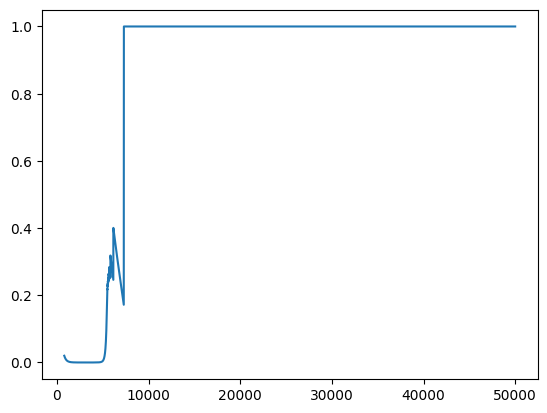

In [33]:
plt.plot(wave_grid,calc_transmission(5,wave_grid))

(array([3807., 3996., 3430., 3799., 2854., 3477., 2667., 2741., 3337.,
         905., 2522., 1596., 1857., 2600., 1379., 1964., 1017., 1397.,
         726., 1316., 1703., 1378.,  870.,  422.,  265.,  221.,  161.,
         269.,  109.,  104.]),
 array([3.00000405, 3.09999466, 3.19998527, 3.29997587, 3.39996648,
        3.49995708, 3.59994745, 3.69993806, 3.79992867, 3.89991927,
        3.99990988, 4.09990025, 4.19989109, 4.29988146, 4.3998723 ,
        4.49986267, 4.59985352, 4.69984388, 4.79983473, 4.8998251 ,
        4.99981594, 5.09980631, 5.19979668, 5.29978752, 5.39977789,
        5.49976873, 5.5997591 , 5.69974995, 5.79974031, 5.89973116,
        5.99972153]),
 <BarContainer object of 30 artists>)

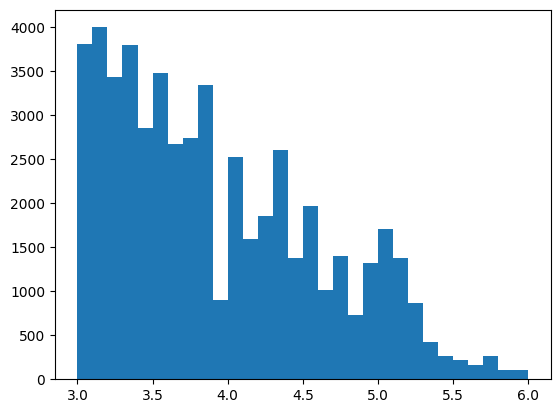

In [31]:
z=df['ez_z_phot']
mask1=3<z
mask2=z<6
plt.hist(z[mask1][mask2],bins=30)

In [19]:
z[mask]

1057      7.237598
1929      7.181131
2402      7.077415
3247      6.070688
3514      6.952714
            ...   
380218    7.281501
380643    6.951839
380849    6.479117
381463    7.307168
381549    6.709391
Name: ez_z_phot, Length: 1118, dtype: float32

In [21]:
c=np.argsort(z[mask])
h=[z[mask].tolist()[i] for i in c] 

In [22]:
h

[6.000245094299316,
 6.000810146331787,
 6.0041069984436035,
 6.004556655883789,
 6.008801460266113,
 6.0089111328125,
 6.00965690612793,
 6.010455131530762,
 6.012717247009277,
 6.012846946716309,
 6.013006687164307,
 6.013796329498291,
 6.01473331451416,
 6.01511287689209,
 6.015992164611816,
 6.016159534454346,
 6.016768455505371,
 6.017458438873291,
 6.018779754638672,
 6.0208659172058105,
 6.020943641662598,
 6.021072864532471,
 6.021426677703857,
 6.022365093231201,
 6.023316860198975,
 6.023343563079834,
 6.024639129638672,
 6.026073932647705,
 6.026644706726074,
 6.027032852172852,
 6.0271382331848145,
 6.027981281280518,
 6.029445171356201,
 6.030323505401611,
 6.030557632446289,
 6.031312465667725,
 6.031961917877197,
 6.032139778137207,
 6.034675598144531,
 6.035844802856445,
 6.0363054275512695,
 6.036987781524658,
 6.038111686706543,
 6.038832187652588,
 6.039074897766113,
 6.040020942687988,
 6.040726184844971,
 6.041967868804932,
 6.042321681976318,
 6.043675422668457,
 

# Fitting for $\tau$ (IGM)

In [18]:
Fz=f_interp_vec(z)

In [19]:
F0 = np.einsum('bk,bkm->bm', bi_all_initial, Fz)

In [20]:
zT  = z_grid1                       # (Nz,)

Tigm_table = np.empty((len(zT), len(wave_grid)), dtype=np.float32)

for iz, z0 in enumerate(zT):
    trans = calc_transmission(z0, wave_grid*(1+z0))          # must return (M,) in [0,1]
    Tigm_table[iz] = trans.astype(np.float32)

Tigm_interp = RegularGridInterpolator((zT,), Tigm_table, bounds_error=False, fill_value=None)


In [21]:
lam1=[]
for i in filters:
    lam1.append(np.mean(i.wavelength))
lam1 = np.asarray(lam1)  

In [22]:
eps = 1e-5
tau_max = 0.85

n_tau = 5000
n1 = 4000                     # points near 0
n2 = n_tau - n1              # points in tail

# Part 1: very dense near 0
taus1 = np.linspace(0.0, eps, n1, dtype=np.float64)

# Part 2: log-spaced tail (efficient coverage)
taus2 = np.logspace(np.log10(eps), np.log10(tau_max), n2, dtype=np.float64)

taus = np.unique(np.concatenate([taus1, taus2])).astype(np.float32)
taus[0] = 0.0


In [23]:
#taus = np.linspace(0.0, 1.0, 1000).astype(np.float32)
batch_size = 10000
chi2_all = np.empty((N, len(taus)), dtype=np.float32)

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    B = b_end - b_start

    Yb = Y[b_start:b_end].astype(np.float32)
    Rb = R[b_start:b_end].astype(np.float32)
    zb = z[b_start:b_end]

    valid = np.isfinite(Yb) & np.isfinite(Rb)
    Yb0 = np.nan_to_num(Yb, nan=0.0, posinf=0.0, neginf=0.0)
    Rb0 = np.nan_to_num(Rb, nan=np.inf, posinf=np.inf, neginf=np.inf)
    W = (1.0 / np.maximum(Rb0, 1e-6)) * valid.astype(np.float32)

    F0_b = F0[b_start:b_end].astype(np.float32)

    wave_z = np.einsum('k,b->bk', wave_grid, (1 + zb))  # (B,M)

    # --- searchsorted per row (syntax-correct) ---
    i = np.array([
        np.searchsorted(wave_z[b], lam1) for b in range(B)
    ])
    i = np.clip(i, 1, wave_z.shape[1] - 1)
    rows = np.arange(B)[:, None]          # (B,1) broadcastable
    left  = wave_z[rows, i - 1]           # (B,L)
    right = wave_z[rows, i]               # (B,L)
    
    choose_right = np.abs(right - lam1) < np.abs(left - lam1)
    i_near = i.copy()
    i_near[~choose_right] -= 1

    # full curve then pick the wavelength bin
    T_curve = Tigm_interp(zb).astype(np.float32)   # (B,M)
    rows = np.arange(B)[:, None]          # (B,1)
    T_lam0 = T_curve[rows, i_near]        # (B,26)        # (B,)

    chi2_batch = np.empty((B, len(taus)), dtype=np.float32)
    for it, t in enumerate(taus):
        model = F0_b * np.exp(-t * T_lam0)  # (B,M)
        resid = Yb0 - model
        chi2_batch[:, it] = np.sum(W * resid * resid, axis=1)

    chi2_all[b_start:b_end] = chi2_batch


KeyboardInterrupt: 

In [244]:
taus = np.linspace(0.0, 1.0, 500).astype(np.float32)
batch_size = 10000

chi2_all  = np.full((N, len(taus)), np.nan, dtype=np.float32)
tau_best_grid  = np.full((N,), 1.0, dtype=np.float32)   # <-- baseline default (recommended)

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    B = b_end - b_start

    Yb = Y[b_start:b_end]
    zb = z[b_start:b_end]                        # (B,)
    Rb = R[b_start:b_end]
    F0_b = F0[b_start:b_end]

    T_lam0 = T_lam0_all[b_start:b_end]

    mask = (T_lam0 < 0.9)

    finite = np.isfinite(Yb) & np.isfinite(Rb)
    valid = finite & mask
    n_aff = np.sum(valid, axis=1)   # (B,)

    solve = n_aff >= 2

    Yb0 = np.nan_to_num(Yb, nan=0.0, posinf=0.0, neginf=0.0)
    Rb0 = np.nan_to_num(Rb, nan=np.inf, posinf=np.inf, neginf=np.inf)

    W_full = (1.0 / Rb0) * valid.astype(np.float32) 

    chi2_batch = np.full((B, len(taus)), np.nan, dtype=np.float32)
    if np.any(solve):
        Ys   = Yb0[solve]
        Ws   = W_full[solve]
        F0s  = F0_b[solve]
        Ts   = T_lam0[solve]

        for it, t in enumerate(taus):
            model = F0s * (Ts ** t)
            resid = Ys - model
            chi2_batch[solve, it] = np.sum(Ws * resid * resid, axis=1)
        idx = np.nanargmin(chi2_batch[solve], axis=1)
        tau_best_grid[b_start:b_end][solve] = taus[idx]
    chi2_all[b_start:b_end] = chi2_batch


In [245]:
tau_best_grid

array([1., 1., 1., ..., 1., 1., 1.], dtype=float32)

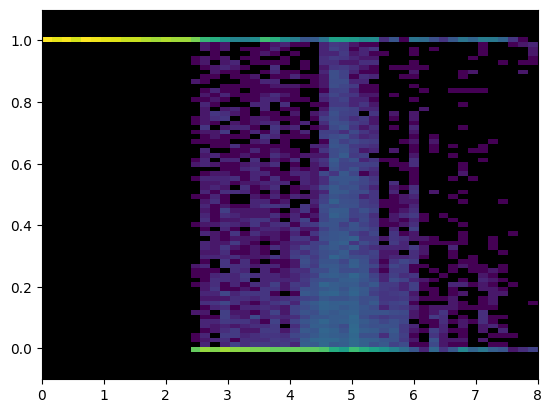

In [268]:
from matplotlib.colors import LogNorm

cmap = plt.cm.viridis.copy()
cmap.set_bad(color="black")  
plt.hist2d(z,tau_best_grid,bins=[50, 80],cmap=cmap,range=[[0, 8], [-0.1, 1.1]],norm=LogNorm())
plt.show()

In [48]:
def fit_tau_newton(F0, Y, Rinv, T_igm, tau0=0.5, niter=6):
    # F0, Y, Rinv, T_igm: all (B,26)
    tau = np.full((F0.shape[0],), tau0, dtype=np.float32)

    for p in range(niter):
        g  = np.exp(-T_igm * tau[:, None])   # (B,26)
        f  = F0 * g                          # (B,26)
        Tf = T_igm * f                       # (B,26)
        r  = (Y - f)                         # (B,26)

        grad = 2.0 * np.sum(Rinv * r * Tf, axis=1)   # (B,)
        hess =  2.0 * np.sum(Rinv * Tf * Tf, axis=1)  # (B,)

        step = grad / np.maximum(hess, 1e-30)
        tau  = tau - step
        #tau  = np.clip(tau, 0.0, 10.0)  # keep the guardrail
    return tau


In [20]:
def fit_tau_newton_new(F0, Y, Rinv, T_igm, tau0=0.5, niter=6):
    # F0, Y, Rinv, T_igm: all (B,26)
    tau = np.full((F0.shape[0],), tau0, dtype=np.float32)

    tau_eff = (-np.log(T_igm)).astype(np.float32)            # (B,L), >=0

    for _ in range(niter):
        g  = np.exp(-tau_eff * tau[:, None])             # (B,L)
        f  = F0 * g                                      # (B,L)
        df = -tau_eff * f                                # (B,L)
        r = (f-Y)                                      # (B,L)
        grad = 2.0 * np.sum(Rinv * r * df, axis=1)      # (B,)
        hess =  2.0 * np.sum(Rinv * df * df, axis=1)     # (B,)
        step = grad / np.maximum(hess, 1e-30)
        tau  = tau - step
    return tau


In [22]:
import numpy as np

valid = np.isfinite(Y) & np.isfinite(R)
Y0    = np.nan_to_num(Y, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
R0    = np.nan_to_num(R, nan=np.inf, posinf=np.inf, neginf=np.inf).astype(np.float32)

# IMPORTANT: assumes R is variance. If R is sigma, use 1/R0**2 instead.
Rinv0 = (1.0 /R0)

batch_size = 50000
tau_best   = np.empty((N,), dtype=np.float32)

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    B = b_end - b_start

    Yb    = Y0[b_start:b_end]                      # (B,L)
    Rinvb = Rinv0[b_start:b_end]                   # (B,L)
    F0_b  = F0[b_start:b_end]   # (B,L)
    T_lam0 = T_lam0_all[b_start:b_end]
    mask = (T_lam0 < 0.9)                           # (B,L)

    # finite + affected
    keep = mask & valid[b_start:b_end]              # (B,L)

    # masked inverse-variance weights
    W = Rinvb * keep.astype(np.float32)             # (B,L)

    # number of affected bands per galaxy
    n_aff = np.sum(keep, axis=1)                    # (B,)

    # default baseline (mean IGM)
    tau_hat = np.full((B,), 1.0, dtype=np.float32)

    # only solve where identifiable
    solve = n_aff >= 2
    if np.any(solve):
        tau_hat[solve] = fit_tau_newton_new(
            F0_b[solve], Yb[solve], W[solve], T_lam0[solve],
            tau0=1.0, niter=10
        ).astype(np.float32)

    # enforce baseline for <2 affected bands (your request)
    tau_hat[n_aff < 2] = 1.0

    tau_best[b_start:b_end] = tau_hat


C:\Users\pranav\AppData\Local\Temp\ipykernel_25212\3512880810.py:8: RuntimeWarning: overflow encountered in exp
  g  = np.exp(-tau_eff * tau[:, None])             # (B,L)
C:\Users\pranav\AppData\Local\Temp\ipykernel_25212\3512880810.py:9: RuntimeWarning: invalid value encountered in multiply
  f  = F0 * g                                      # (B,L)
C:\Users\pranav\AppData\Local\Temp\ipykernel_25212\3512880810.py:12: RuntimeWarning: overflow encountered in multiply
  grad = 2.0 * np.sum(Rinv * r * df, axis=1)      # (B,)
C:\Users\pranav\AppData\Local\Temp\ipykernel_25212\3512880810.py:13: RuntimeWarning: overflow encountered in multiply
  hess =  2.0 * np.sum(Rinv * df * df, axis=1)     # (B,)
C:\Users\pranav\AppData\Local\Temp\ipykernel_25212\3512880810.py:14: RuntimeWarning: invalid value encountered in divide
  step = grad / np.maximum(hess, 1e-30)
C:\Users\pranav\AppData\Local\Temp\ipykernel_25212\3512880810.py:12: RuntimeWarning: invalid value encountered in multiply
  grad = 2.0 

In [131]:
c,u=np.unique(tau_best,return_counts=True)

In [23]:
np.nanmax(tau_best)

1.6400067e+16

In [170]:
k=214075
z[k],tau_best[k]

(2.913024, -33.221107)

In [196]:
g=Y[k]

In [195]:
h=bi_all_initial[k][0]*F_pca[k][0]+bi_all_initial[k][1]*F_pca[k][1]+bi_all_initial[k][2]*F_pca[k][2]+bi_all_initial[k][3]*F_pca[k][3]

In [194]:
h1=bi_all_initial[k][0]*F_pca[k][0]*(T_lam0_all[k]**tau_best[k])+bi_all_initial[k][1]*F_pca[k][1]*(T_lam0_all[k]**tau_best[k])+bi_all_initial[k][2]*F_pca[k][2]*(T_lam0_all[k]**tau_best[k])+bi_all_initial[k][3]*F_pca[k][3]*(T_lam0_all[k]**tau_best[k])

In [49]:
t=pd.Series(tau_best)
t.describe()

count    3.816160e+05
mean    -2.332070e-03
std      2.131282e-02
min     -1.145115e+00
25%     -8.714509e-08
50%     -2.242757e-08
75%      2.329907e-08
max      7.873037e-01
dtype: float64

In [32]:
np.save('tau.npy',tau_best_grid)

In [21]:
tau=np.load('tau.npy')
T_lam0_all=np.load('Tigm.npy')

In [87]:
F_pca=f_interp_vec(z)

In [92]:
#A = np.exp(-tau[:, None] * T_lam0_all).astype(np.float32)   # (N,B)
A=T_lam0_all**tau_best_grid[:,None]
F_tau = F_pca * (A[:,None,:])    # (N,K,B)

In [97]:
A[np.argmin(z)],tau_best_grid[np.argmin(z)]

(array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32),
 0.0)

All batches processed. Generating plots...


<Figure size 640x480 with 0 Axes>

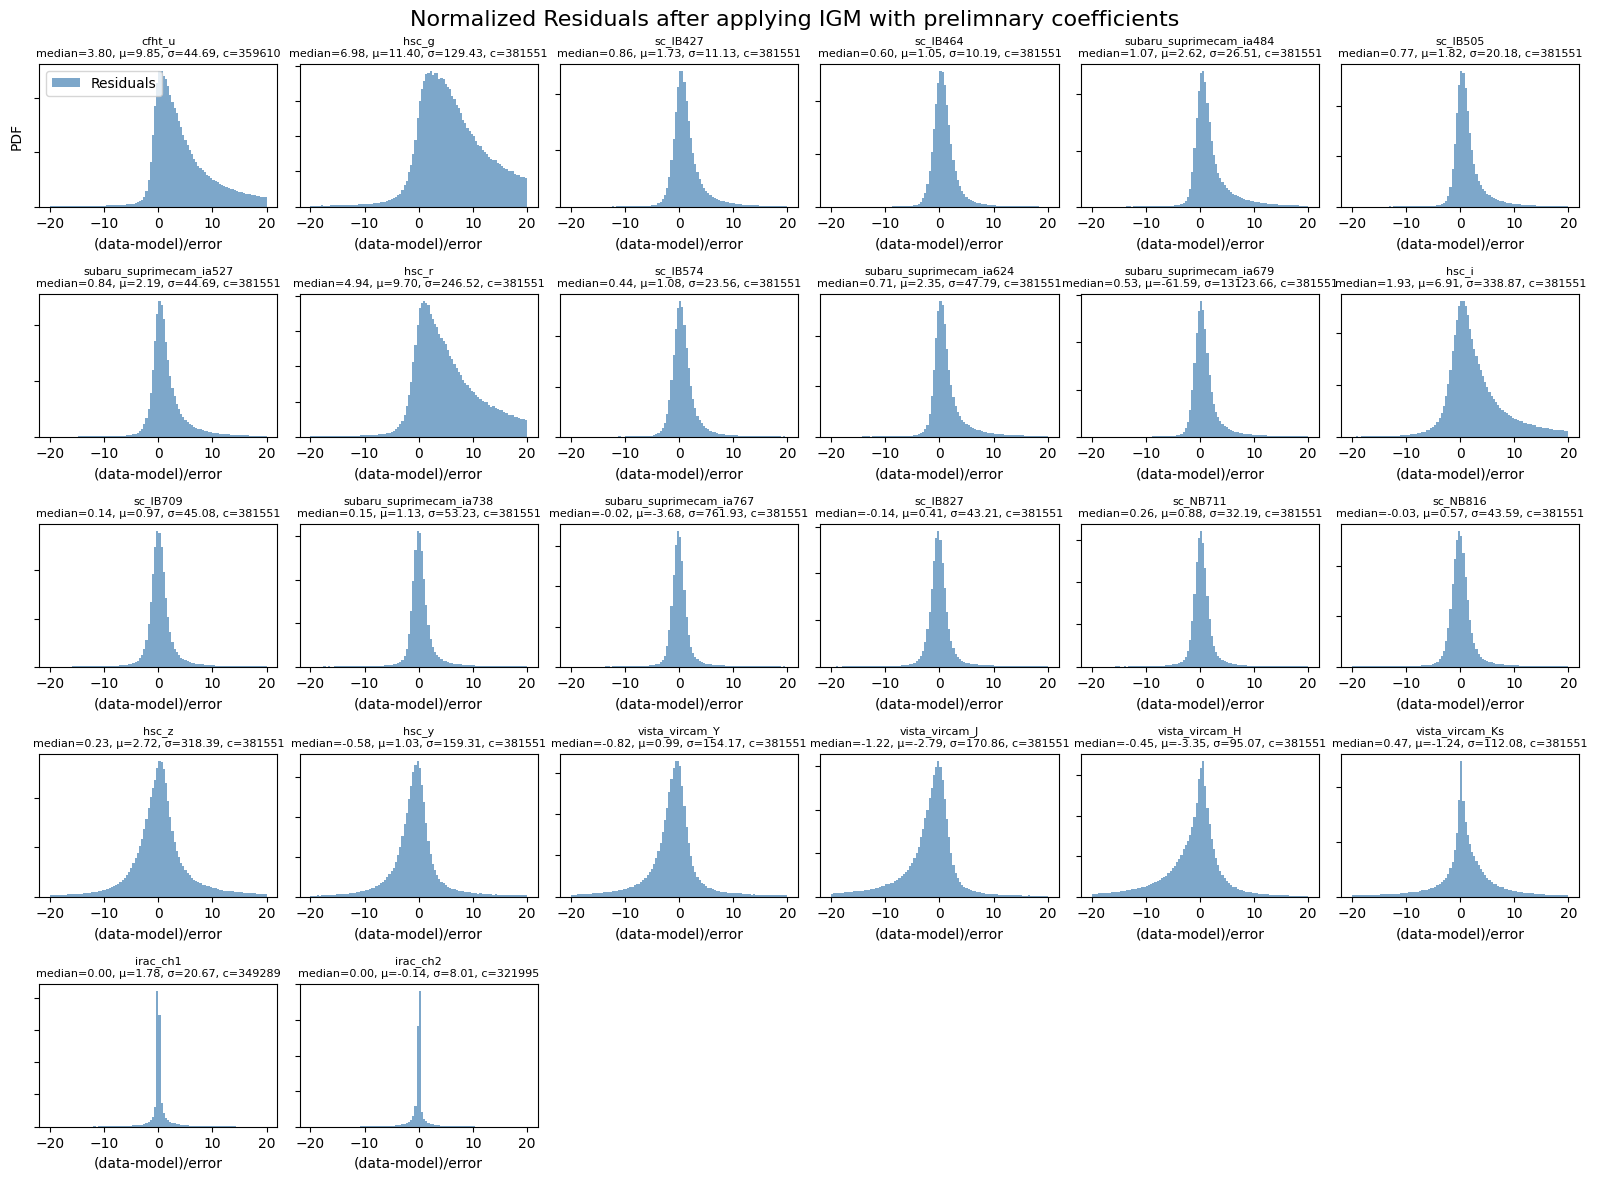

<Figure size 640x480 with 0 Axes>

In [270]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.interpolate import RegularGridInterpolator
from sedpy.observate import load_filters
plt.clf()
filters = load_filters(fil)

batch_size = 50000

fig, axes = plt.subplots(5, 6, figsize=(16, 12))
axes = axes.flatten()
N_bands = len(fil)
N_bands_to_plot = N_bands

all_residuals_tau = [[] for _ in range(N_bands_to_plot)]

galaxy_coefficients = bi_all_initial

c = F_tau

model_fluxes_batch = np.einsum('nk,nkb->nb', galaxy_coefficients, c)

data_batch = df_flux.to_numpy()
error_batch = df_err.to_numpy()
lya_obs_all = 1216.0 * (1.0 + z)

for i in range(N_bands_to_plot):
    
    data = data_batch[:, i]
    error = error_batch[:, i]
    model = model_fluxes_batch[:, i]

    is_not_affected = lam[i] >= lya_obs_all

    mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6) 
    
    data_m = data[mask]
    error_m = error[mask]
    model_m = model[mask]

    if len(data_m) == 0:
        continue

    r_batch = (data_m - model_m) / error_m
    
    all_residuals_tau[i].append(r_batch)

print("All batches processed. Generating plots...")

for i in range(N_bands_to_plot):
    ax = axes[i]
    
    if not all_residuals_tau[i]:
        ax.set_title(f"{fil[i]}\nNo valid data")
        continue
        
    r_tau = all_residuals_tau[i]

    ax.hist(r_tau, bins=100, range=(-20,20), density=True, alpha=0.7, color='steelblue', label='Residuals')    
    mu, median, sd, count = np.nanmean(r_tau), np.nanmedian(r_tau), np.nanstd(r_tau), len(r_tau[0])
    ax.set_title(f"{fil[i]}\nmedian={median:.2f}, μ={mu:.2f}, σ={sd:.2f}, c={count}", fontsize=8)
    #ax.set_yscale('log')
    ax.set_xlabel("(data-model)/error")
    ax.set_yticklabels([])
    

axes[0].set_ylabel("PDF")
axes[0].legend()

for j in range(N_bands_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Normalized Residuals after applying IGM with prelimnary coefficients', fontsize=16)
plt.tight_layout()
plt.savefig('Step2.png')
plt.show()
plt.tight_layout()


# Using $\tau$

In [118]:
import numpy as np

lam1 = np.asarray([np.mean(f.wavelength) for f in filters], dtype=np.float32)  # (L,)
L = lam1.size
M = wave_grid.size

# Preallocate output
T_lam0_all = np.empty((N, L), dtype=np.float32)

batch_size = 10000

for b_start in range(0, N, batch_size):
    b_end = min(b_start + batch_size, N)
    B = b_end - b_start

    zb = z[b_start:b_end].astype(np.float32)  # (B,)

    # rest-frame wavelengths per galaxy per filter
    wave_z = np.einsum('k,b->bk', wave_grid, (1 + zb))  # (B,M)

    # --- searchsorted per row (syntax-correct) ---
    i = np.array([
        np.searchsorted(wave_z[b], lam1) for b in range(B)
    ])
    i = np.clip(i, 1, wave_z.shape[1] - 1)
    rows = np.arange(B)[:, None]          # (B,1) broadcastable
    left  = wave_z[rows, i - 1]           # (B,L)
    right = wave_z[rows, i]               # (B,L)
    
    choose_right = np.abs(right - lam1) < np.abs(left - lam1)
    i_near = i.copy()
    i_near[~choose_right] -= 1

    # Evaluate Tigm curve on full wavelength grid for these galaxies
    T_curve = Tigm_interp(zb).astype(np.float32)         # (B,M)

    rows = np.arange(B)[:, None]
    T_lam0 = T_curve[rows, i_near].astype(np.float32)    # (B,L)

    T_lam0_all[b_start:b_end] = T_lam0

# Optionally save
#np.save("T_lam0_all.npy", T_lam0_all)


In [160]:
np.save("Tigm.npy", T_lam0_all)

In [9]:
from scipy.interpolate import RegularGridInterpolator
f_all = np.load('pcaflux_w_redshift1.npy')   # shape: (Nz, Kc, Nbands)
z_grid1=np.load('zgrid.npy')
f_interp_vec = RegularGridInterpolator((z_grid1,), f_all, bounds_error=False, fill_value=None)
z = df['ez_z_phot'].to_numpy()

In [37]:
import numpy as np
import pandas as pd
from sedpy.observate import getSED, load_filters
from scipy.interpolate import RegularGridInterpolator
import time
import matplotlib.pyplot as plt
plt.clf()

lam=[]
for i in filters:
    lam.append(np.percentile(i.wavelength,90))
lam = np.asarray(lam)  

f_all = np.load('pcaflux_w_redshift1.npy')   # shape: (Nz, Kc, Nbands)
z_grid1=np.load('zgrid.npy')
f_interp_vec = RegularGridInterpolator((z_grid1,), f_all, bounds_error=False, fill_value=None)

alpha3 = np.load('alpha3.npy')
N_bands = len(fil)
Kc = 4
LL=[]

z = df['ez_z_phot'].to_numpy()
mask = np.isfinite(z) & (z<8)

z = z[mask]
Y = np.asarray(df_flux[mask], dtype=float)
S = np.asarray(df_err[mask], dtype=float)
R = S**2

N, M = Y.shape
assert M == N_bands
Sigma_c = np.cov(alpha3, rowvar=False)

try:
    Sigma_c_inv = np.linalg.inv(Sigma_c)
except:
    Sigma_c_inv = np.linalg.pinv(Sigma_c)

mu=np.mean(alpha3)
batch_size = 50000

start = time.time()
bi_all = np.zeros((N, Kc))   # store full posterior means
batch_idx = 0               # counter to fill bi_all

for b_start in range(0, N, batch_size):
    
    b_end = min(b_start + batch_size, N)
    Yb, Rb = Y[b_start:b_end], R[b_start:b_end]
    zb = z[b_start:b_end]
    B = b_end - b_start

    Fz = F_tau[b_start:b_end]
    Yb0 = np.nan_to_num(Yb, nan=0.0, posinf=0.0, neginf=0.0)
    Rb0 = np.nan_to_num(Rb, nan=np.inf, posinf=np.inf, neginf=np.inf)
    Rinv = 1.0 / np.maximum(Rb0,1e-6)

    Ai = np.einsum('bkm,bm,bjm->bkj', Fz, Rinv, Fz)
    Ai_full = Ai + Sigma_c_inv[None, :, :]
    try:
        Bi = np.linalg.inv(Ai_full)
    except:
        Bi = np.linalg.pinv(Ai_full)

    rhs1 = np.einsum('bkm,bm->bk', Fz, Rinv * Yb0)
    mu_batch = np.broadcast_to(mu, (B, Kc))
    mu_i_Sigma_inv = np.einsum('bk,kl->bl', mu_batch, Sigma_c_inv)

    bi = np.einsum('bij,bj->bi', Bi, mu_i_Sigma_inv + rhs1)

    # Store the results
    bi_all[b_start:b_end] = bi

<Figure size 640x480 with 0 Axes>

In [34]:
np.save("coef.npy", bi_all_initial)
np.save("coef_igm.npy", bi_all)

In [38]:
import numpy as np
bi_all=np.load('coef_igm.npy')
bi_all_initial=np.load('coef.npy')

All batches processed. Generating plots...


<Figure size 640x480 with 0 Axes>

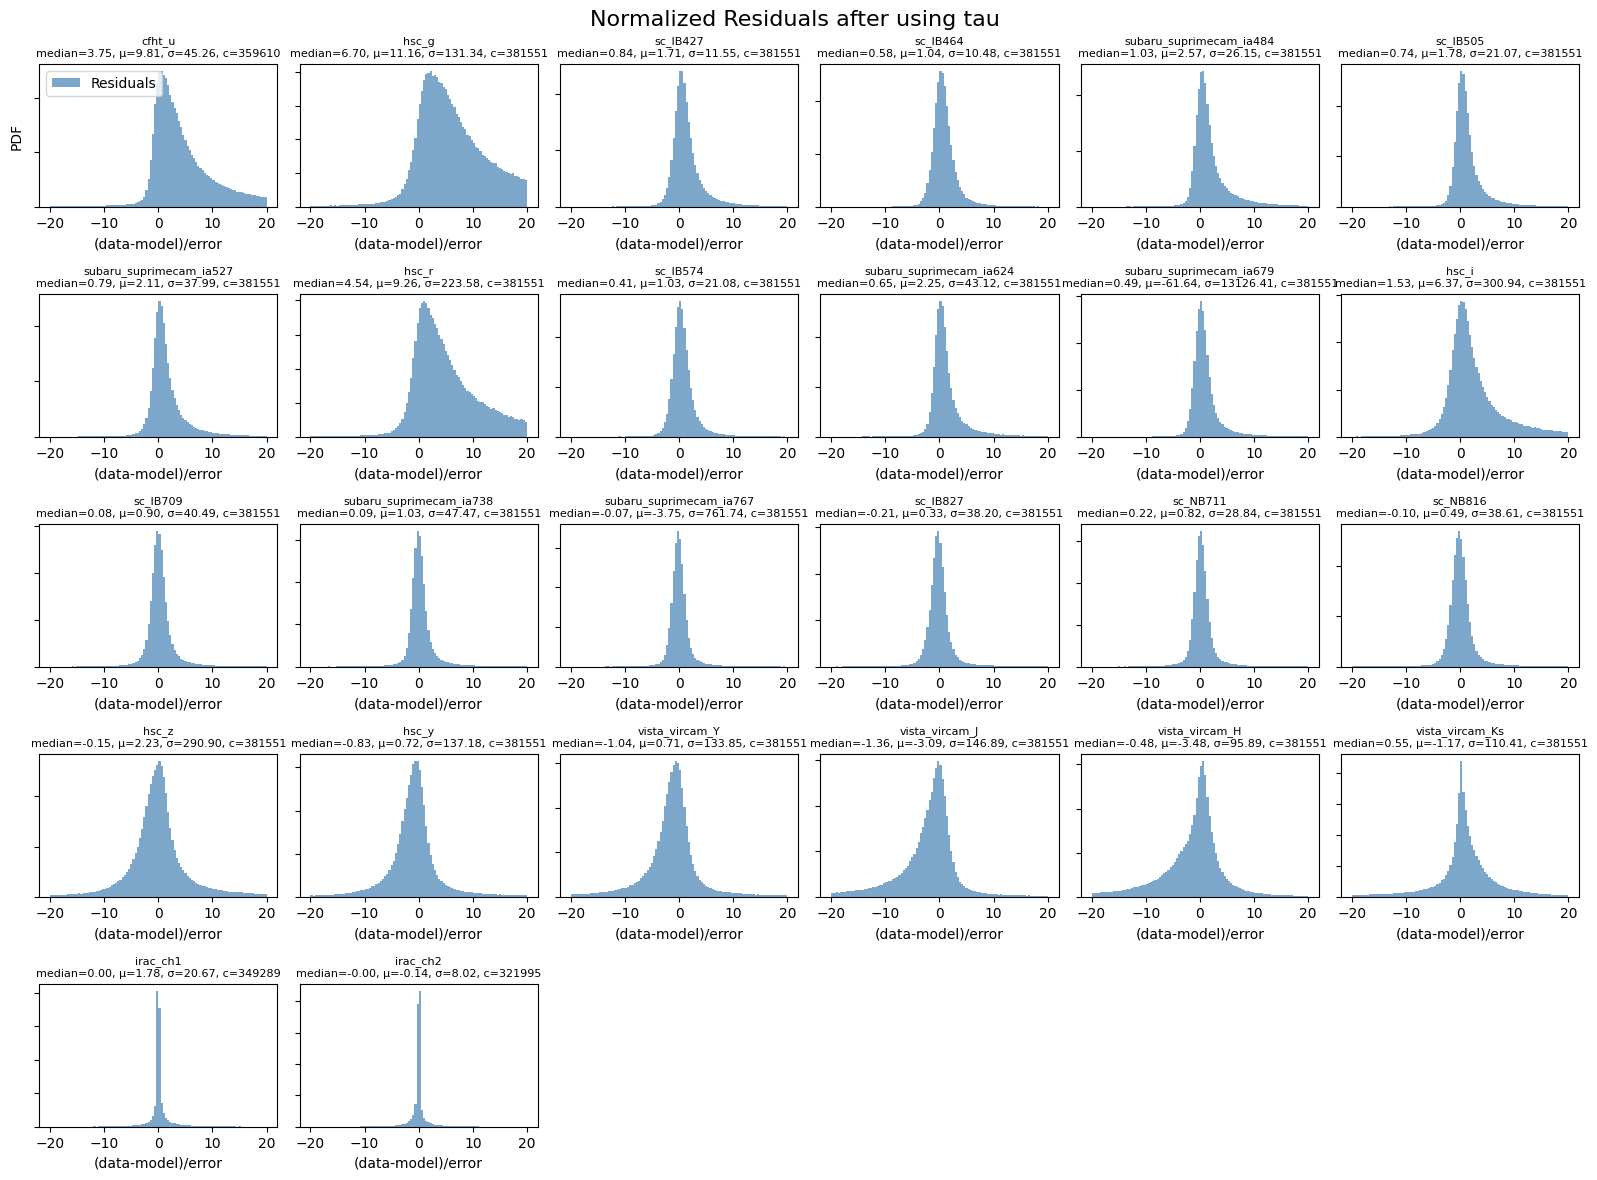

<Figure size 640x480 with 0 Axes>

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from scipy.interpolate import RegularGridInterpolator
from sedpy.observate import load_filters
plt.clf()
filters = load_filters(fil)

batch_size = 50000

fig, axes = plt.subplots(5, 6, figsize=(16, 12))
axes = axes.flatten()
N_bands = len(fil)
N=len(z)

N_bands_to_plot = N_bands

all_residuals_igm = [[] for _ in range(N_bands_to_plot)]

model_fluxes_batch = np.einsum('nk,nkb->nb', bi_all, F_tau)

data_batch = df_flux.to_numpy()
error_batch = df_err.to_numpy()

for i in range(N_bands_to_plot):
    
    data = data_batch[:, i]
    error = error_batch[:, i]
    model = model_fluxes_batch[:, i]

    mask = np.isfinite(data) & np.isfinite(error) & (error > 1e-6) 
    
    data_m = data[mask]
    error_m = error[mask]
    model_m = model[mask]

    if len(data_m) == 0:
        continue

    r_batch = (data_m - model_m) / error_m
    
    all_residuals_igm[i].append(r_batch)

print("All batches processed. Generating plots...")

for i in range(N_bands_to_plot):
    ax = axes[i]
    
    if not all_residuals_igm[i]:
        ax.set_title(f"{fil[i]}\nNo valid data")
        continue
        
    r1 = all_residuals_igm[i]

    ax.hist(r1, bins=100, range=(-20,20), density=True, alpha=0.7, color='steelblue', label='Residuals')    
    mu, median, sd,count = np.nanmean(r1), np.nanmedian(r1), np.nanstd(r1),len(r1[0])
    ax.set_title(f"{fil[i]}\nmedian={median:.2f}, μ={mu:.2f}, σ={sd:.2f}, c={count}", fontsize=8)
    #ax.set_yscale('log')
    ax.set_xlabel("(data-model)/error")
    ax.set_yticklabels([])
    

axes[0].set_ylabel("PDF")
axes[0].legend()

for j in range(N_bands_to_plot, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Normalized Residuals after using tau', fontsize=16)
plt.tight_layout()
plt.savefig('Step3.png')
plt.show()
plt.tight_layout()


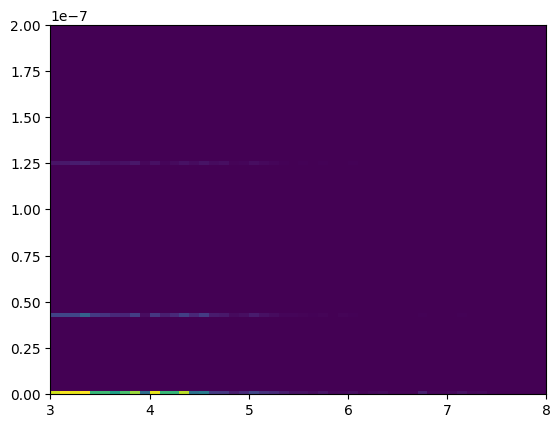

In [94]:
zmin, zmax,ymax,ymin = [3, 8,0.0000002,0]
mask=z>3
plt.hist2d(z[mask], tau[mask],bins=[50, 100],cmap="viridis",range=[[zmin, zmax], [ymin, ymax]])
plt.show()

In [137]:
pd.Series(tau).describe()

count    3.816160e+05
mean     1.727571e-05
std      1.033314e-03
min      0.000000e+00
25%      2.175544e-07
50%      1.522881e-06
75%      5.298825e-06
max      5.395663e-01
dtype: float64

In [131]:
f=z[274073]

In [134]:
1216*(1+f)

10942.972534179688

In [135]:
lam

array([ 3958.  ,  5750.  ,  4409.7 ,  4801.6 ,  5011.5 ,  5253.6 ,
        5442.  ,  7250.  ,  5993.5 ,  6460.  ,  7098.  ,  8740.  ,
        7337.05,  7582.  ,  7902.5 ,  8462.75,  7301.1 ,  8301.82,
        9447.  , 10755.  , 28373.68, 24466.  , 23080.  , 23217.  ,
       38929.6 , 50197.7 ])

In [127]:
T_lam0_all[274073]

array([7.7254154e-11, 7.7254154e-11, 7.7254154e-11, 7.7254154e-11,
       7.7254154e-11, 7.7254154e-11, 7.7254154e-11, 7.7254154e-11,
       7.7254154e-11, 7.7254154e-11, 7.7254154e-11, 9.1085062e-10,
       7.7254154e-11, 1.7470382e-10, 6.9041362e-10, 9.8182653e-09,
       7.7254154e-11, 3.3413552e-09, 1.3198897e-06, 9.5788124e-08,
       1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
       1.0000000e+00, 1.0000000e+00], dtype=float32)

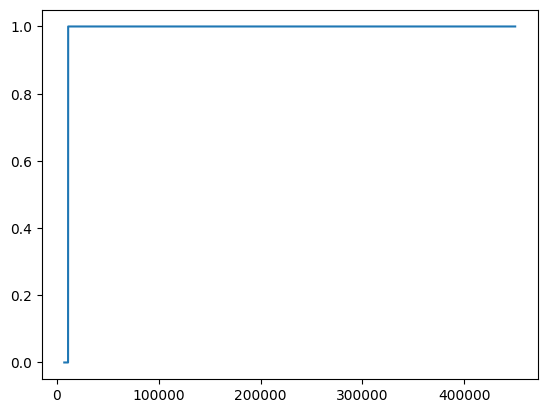

In [136]:
plt.plot(wave_grid*(1+f),calc_transmission(f,wave_grid*(1+f)))

(-0.0001, 0.002)

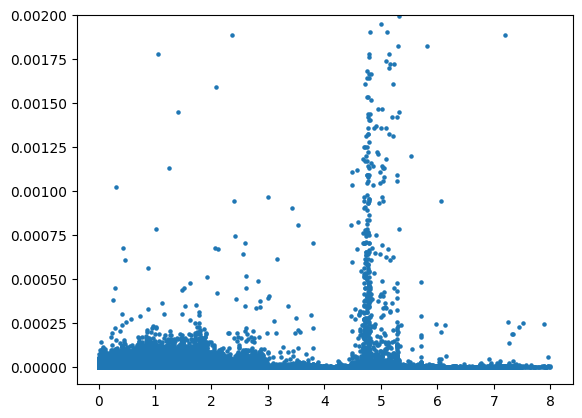

In [112]:
plt.scatter(z,tau*T_lam0_all[:,25],s=5)
plt.ylim(-0.0001,0.002)

(0.0, 4000.0)

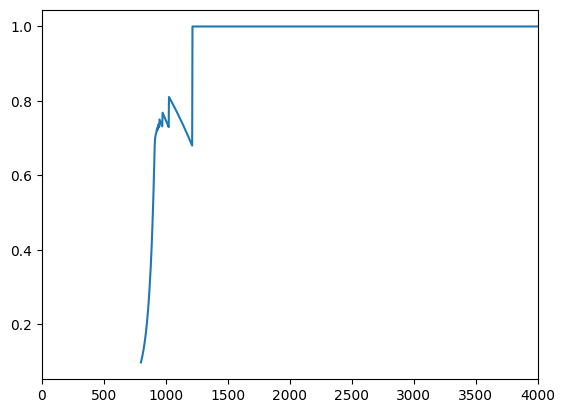

In [105]:
plt.plot(wave_grid,calc_transmission(3,wave_grid*(1+3)))
plt.xlim(0,4000)